# **Importing all the Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# **Defining the Location**

In [2]:
LATITUDE = 32.1877
LONGITUDE = 74.1945

START_DATE = "2024-01-01"
END_DATE = "2026-07-31"

TIMEZONE = "Asia/Karachi"

# **Fetching & Storing Weather Data**

In [4]:
weather_url = "https://archive-api.open-meteo.com/v1/archive"

weather_params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "hourly": ",".join([
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
        "surface_pressure",
        "precipitation",
        "cloud_cover"
    ]),
    "timezone": TIMEZONE
}

response = requests.get(weather_url, params=weather_params)

print(response.status_code)

weather_data = response.json()

weather_data.keys()


200


dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])

In [5]:
weather_df = pd.DataFrame(weather_data["hourly"])


In [7]:
weather_df.head()

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover
0,2024-01-01T00:00,7.4,100,7.1,991.7,0.0,99
1,2024-01-01T01:00,7.0,98,2.8,991.7,0.0,100
2,2024-01-01T02:00,7.0,100,2.7,991.6,0.0,100
3,2024-01-01T03:00,7.1,99,2.5,991.7,0.0,100
4,2024-01-01T04:00,7.1,98,1.8,991.4,0.0,100


In [8]:
weather_df.describe()

,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover
count,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000
mean,23.616989,63.666976,7.146072,982.187831,0.090116,33.250353
std,8.848786,23.246150,4.102802,6.967652,0.651678,40.908243
min,2.600000,7.000000,0.000000,964.700000,0.000000,0.000000
25%,16.700000,46.000000,4.200000,976.400000,0.000000,0.000000
50%,25.100000,66.000000,6.600000,982.300000,0.000000,8.000000
75%,30.200000,84.000000,9.500000,988.000000,0.000000,80.000000
max,45.500000,100.000000,36.300000,1001.200000,32.500000,100.000000


In [10]:
weather_df.shape

(22632, 7)

In [11]:
weather_df.tail(10)

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover
22622,2026-07-31T14:00,27.6,90,9.7,975.2,1.1,98
22623,2026-07-31T15:00,28.7,87,7.2,974.4,0.2,100
22624,2026-07-31T16:00,29.4,83,8.0,974.0,0.1,99
22625,2026-07-31T17:00,30.4,75,10.9,973.8,0.1,98
22626,2026-07-31T18:00,29.9,79,9.2,973.7,0.1,99
22627,2026-07-31T19:00,29.2,81,10.0,973.8,0.0,98
22628,2026-07-31T20:00,28.7,82,8.5,974.4,0.0,93
22629,2026-07-31T21:00,28.4,83,7.1,974.8,0.0,94
22630,2026-07-31T22:00,28.2,83,7.1,975.2,0.0,48
22631,2026-07-31T23:00,28.3,82,7.6,975.4,0.0,66


In [12]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22632 entries, 0 to 22631
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  22632 non-null  object 
 1   temperature_2m        22632 non-null  float64
 2   relative_humidity_2m  22632 non-null  int64  
 3   wind_speed_10m        22632 non-null  float64
 4   surface_pressure      22632 non-null  float64
 5   precipitation         22632 non-null  float64
 6   cloud_cover           22632 non-null  int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 1.2+ MB


# **Fetching & Storing Air Quality Data**

In [14]:
aq_url = "https://air-quality-api.open-meteo.com/v1/air-quality"

aq_params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "hourly": ",".join([
        "pm10",
        "pm2_5",
        "carbon_monoxide",
        "nitrogen_dioxide",
        "sulphur_dioxide",
        "ozone",
        "us_aqi"
    ]),
    "timezone": TIMEZONE
}

response = requests.get(aq_url, params=aq_params)
print(response.status_code)

aq_data = response.json()

aq_df = pd.DataFrame(aq_data["hourly"])

200


In [17]:
aq_data.keys()

Index(['time', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide',
       'sulphur_dioxide', 'ozone', 'us_aqi'],
      dtype='object')

In [18]:
aq_df.head(10)

,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi
0,2024-01-01T00:00,330.6,231.0,3325.0,57.2,31.0,39.0,242
1,2024-01-01T01:00,330.6,230.5,3166.0,47.2,23.6,44.0,243
2,2024-01-01T02:00,295.2,205.8,2997.0,37.6,17.0,49.0,244
3,2024-01-01T03:00,266.4,186.3,2823.0,29.1,12.1,54.0,244
4,2024-01-01T04:00,254.3,177.4,2641.0,21.1,7.9,60.0,244
5,2024-01-01T05:00,224.4,156.5,2096.0,11.0,8.6,74.0,244
6,2024-01-01T06:00,219.3,153.2,2115.0,11.9,7.2,72.0,245
7,2024-01-01T07:00,221.2,154.6,2140.0,13.2,5.2,71.0,245
8,2024-01-01T08:00,223.5,156.0,2151.0,14.0,3.7,74.0,246
9,2024-01-01T09:00,223.5,156.0,2139.0,13.9,2.8,84.0,246


In [19]:
weather_df["time"] = pd.to_datetime(weather_df["time"])
aq_df["time"] = pd.to_datetime(aq_df["time"])

# **Merging both Data sets**

In [20]:
df = pd.merge(
    weather_df,
    aq_df,
    on="time",
    how="inner")
df.head(10)

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi
0,2024-01-01 00:00:00,7.4,100,7.1,991.7,0.0,99,330.6,231.0,3325.0,57.2,31.0,39.0,242
1,2024-01-01 01:00:00,7.0,98,2.8,991.7,0.0,100,330.6,230.5,3166.0,47.2,23.6,44.0,243
2,2024-01-01 02:00:00,7.0,100,2.7,991.6,0.0,100,295.2,205.8,2997.0,37.6,17.0,49.0,244
3,2024-01-01 03:00:00,7.1,99,2.5,991.7,0.0,100,266.4,186.3,2823.0,29.1,12.1,54.0,244
4,2024-01-01 04:00:00,7.1,98,1.8,991.4,0.0,100,254.3,177.4,2641.0,21.1,7.9,60.0,244
5,2024-01-01 05:00:00,7.0,98,2.8,991.3,0.0,100,224.4,156.5,2096.0,11.0,8.6,74.0,244
6,2024-01-01 06:00:00,7.9,98,2.3,992.0,0.0,100,219.3,153.2,2115.0,11.9,7.2,72.0,245
7,2024-01-01 07:00:00,8.4,98,2.6,992.6,0.0,100,221.2,154.6,2140.0,13.2,5.2,71.0,245
8,2024-01-01 08:00:00,8.8,99,2.6,993.1,0.0,100,223.5,156.0,2151.0,14.0,3.7,74.0,246
9,2024-01-01 09:00:00,9.4,98,2.9,993.6,0.0,100,223.5,156.0,2139.0,13.9,2.8,84.0,246


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22632 entries, 0 to 22631
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  22632 non-null  datetime64[ns]
 1   temperature_2m        22632 non-null  float64       
 2   relative_humidity_2m  22632 non-null  int64         
 3   wind_speed_10m        22632 non-null  float64       
 4   surface_pressure      22632 non-null  float64       
 5   precipitation         22632 non-null  float64       
 6   cloud_cover           22632 non-null  int64         
 7   pm10                  22632 non-null  float64       
 8   pm2_5                 22632 non-null  float64       
 9   carbon_monoxide       22632 non-null  float64       
 10  nitrogen_dioxide      22632 non-null  float64       
 11  sulphur_dioxide       22632 non-null  float64       
 12  ozone                 22632 non-null  float64       
 13  us_aqi          

In [22]:
df.shape

(22632, 14)

# **EDA - Exploratory Data Analysis**

In [23]:
df.isnull().sum()

,0
time,0
temperature_2m,0
relative_humidity_2m,0
wind_speed_10m,0
surface_pressure,0
precipitation,0
cloud_cover,0
pm10,0
pm2_5,0
carbon_monoxide,0


In [24]:
df.describe()

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi
count,22632,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000
mean,2025-04-16 11:29:59.999999744,23.616989,63.666976,7.146072,982.187831,0.090116,33.250353,90.654436,63.776277,722.434738,20.712853,13.518213,96.358475,143.816322
min,2024-01-01 00:00:00,2.600000,7.000000,0.000000,964.700000,0.000000,0.000000,3.100000,2.200000,120.000000,0.000000,0.000000,0.000000,57.000000
25%,2024-08-23 17:45:00,16.700000,46.000000,4.200000,976.400000,0.000000,0.000000,48.100000,31.900000,357.000000,6.900000,8.200000,52.000000,105.000000
50%,2025-04-16 11:30:00,25.100000,66.000000,6.600000,982.300000,0.000000,8.000000,72.200000,48.300000,524.000000,15.200000,11.700000,87.000000,144.000000
75%,2025-12-08 05:15:00,30.200000,84.000000,9.500000,988.000000,0.000000,80.000000,113.400000,77.500000,860.000000,29.000000,16.500000,140.000000,169.000000
max,2026-07-31 23:00:00,45.500000,100.000000,36.300000,1001.200000,32.500000,100.000000,763.700000,348.300000,3837.000000,130.400000,75.500000,255.000000,355.000000
std,NaN,8.848786,23.246150,4.102802,6.967652,0.651678,40.908243,63.947166,48.047906,558.829893,18.378782,7.934291,54.020336,47.035265


In [25]:
df.drop(columns=["time"]).describe()

,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi
count,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000
mean,23.616989,63.666976,7.146072,982.187831,0.090116,33.250353,90.654436,63.776277,722.434738,20.712853,13.518213,96.358475,143.816322
std,8.848786,23.246150,4.102802,6.967652,0.651678,40.908243,63.947166,48.047906,558.829893,18.378782,7.934291,54.020336,47.035265
min,2.600000,7.000000,0.000000,964.700000,0.000000,0.000000,3.100000,2.200000,120.000000,0.000000,0.000000,0.000000,57.000000
25%,16.700000,46.000000,4.200000,976.400000,0.000000,0.000000,48.100000,31.900000,357.000000,6.900000,8.200000,52.000000,105.000000
50%,25.100000,66.000000,6.600000,982.300000,0.000000,8.000000,72.200000,48.300000,524.000000,15.200000,11.700000,87.000000,144.000000
75%,30.200000,84.000000,9.500000,988.000000,0.000000,80.000000,113.400000,77.500000,860.000000,29.000000,16.500000,140.000000,169.000000
max,45.500000,100.000000,36.300000,1001.200000,32.500000,100.000000,763.700000,348.300000,3837.000000,130.400000,75.500000,255.000000,355.000000


# **Data Visualization **

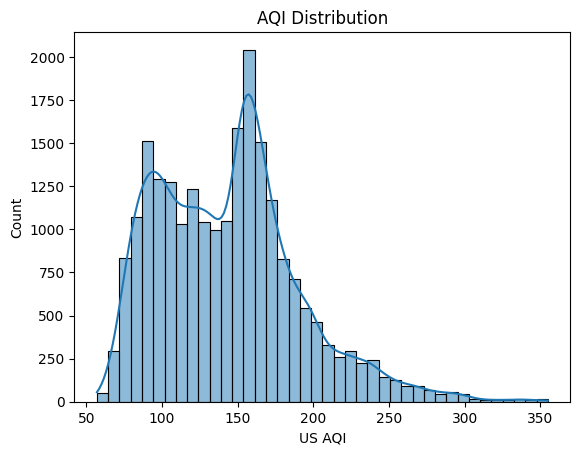

In [26]:
sns.histplot(df["us_aqi"], bins=40, kde=True)

plt.title("AQI Distribution")
plt.xlabel("US AQI")
plt.show()

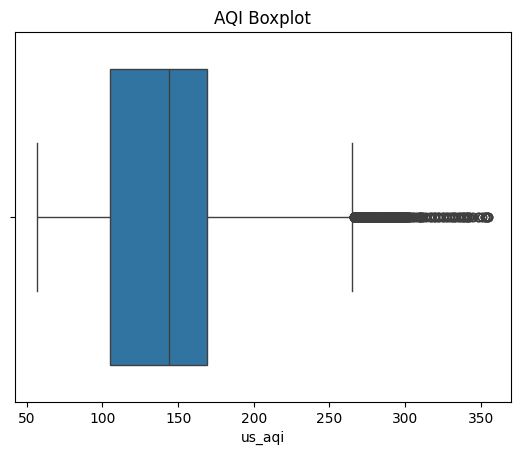

In [28]:
sns.boxplot(x=df["us_aqi"])

plt.title("AQI Boxplot")
plt.show()

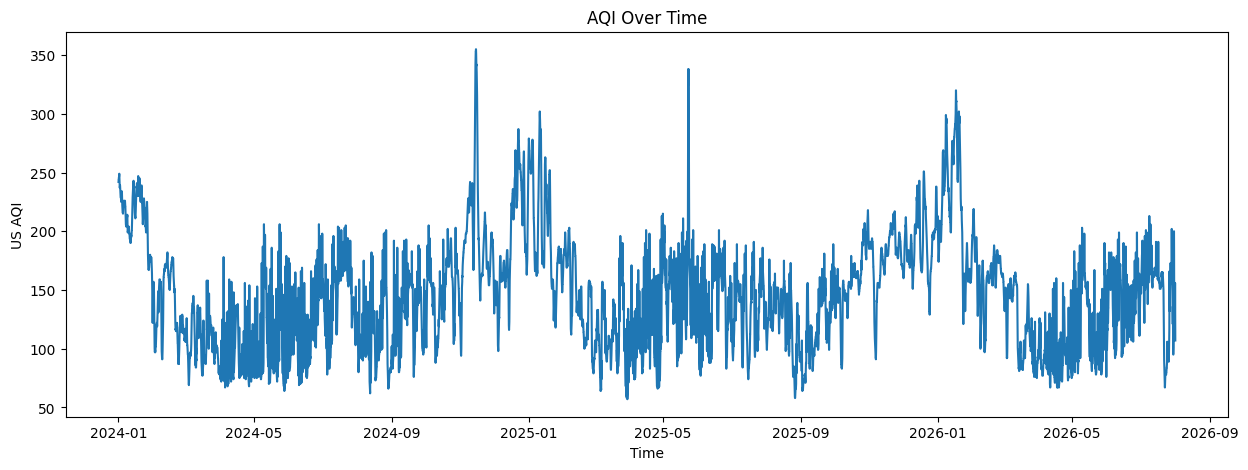

In [29]:
plt.figure(figsize=(15, 5))

plt.plot(df["time"], df["us_aqi"])

plt.title("AQI Over Time")
plt.xlabel("Time")
plt.ylabel("US AQI")

plt.show()

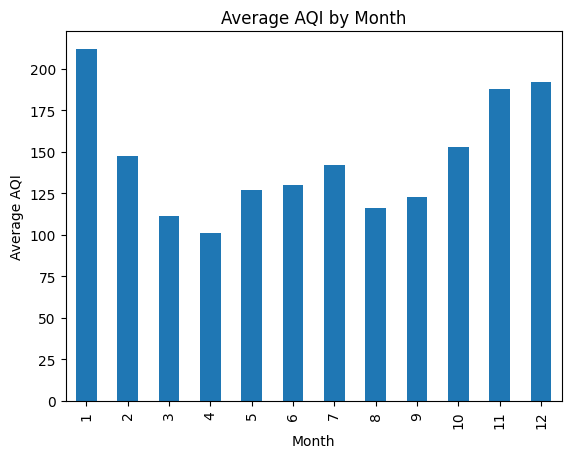

In [32]:
df["month"] = df["time"].dt.month

monthly_aqi = df.groupby("month")["us_aqi"].mean()

monthly_aqi.plot(kind="bar")

plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.show()

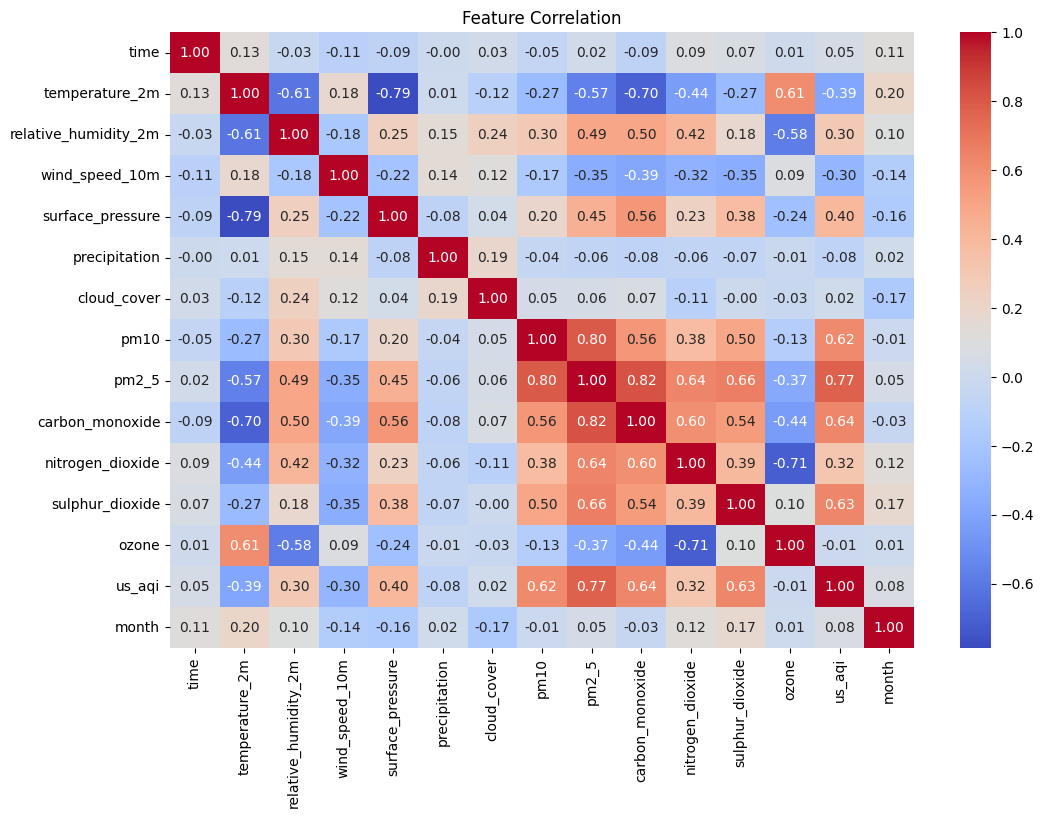

In [33]:
corr = df.corr()
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

In [34]:
corr["us_aqi"].sort_values(ascending=False)

,us_aqi
us_aqi,1.000000
pm2_5,0.771059
carbon_monoxide,0.636397
sulphur_dioxide,0.631165
pm10,0.621284
surface_pressure,0.402725
nitrogen_dioxide,0.321497
relative_humidity_2m,0.295171
month,0.075511
time,0.051356
